# 1. Introduction

In this assignment, a Convolutional Neural Network (CNN) is developed to classify images from the Intel Image Classification dataset. The dataset contains natural scenes such as buildings, forest, glacier, mountain, sea, and street.
---



---



# 2. Dataset Description

The Intel Image Classification dataset consists of six classes: buildings, forest, glacier, mountain, sea, and street. The dataset is divided into training and testing sets.

# 3. Data Preprocessing

All images were resized to 150x150 pixels and normalized. The dataset was loaded using PyTorch's ImageFolder and DataLoader for efficient batching and training.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_dir = "/content/drive/MyDrive/Dataset-CVPR/Intel Image Classification"

train_dir = data_dir + "/seg_train/seg_train"
test_dir = data_dir + "/seg_test/seg_test"

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [4]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_data = datasets.ImageFolder(root=train_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# 4. Model Architecture

A custom CNN architecture was designed with three convolutional layers followed by batch normalization, ReLU activation, and max pooling. Dropout was used in the fully connected layer to reduce overfitting.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Details

The model was trained using the Adam optimizer and cross-entropy loss function. The training process was conducted for multiple epochs, and accuracy and loss were recorded.

In [9]:
!pip install tqdm

In [11]:
epochs = 10

train_loss_list = []
train_acc_list = []

from tqdm import tqdm

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())

    acc = 100 * correct / total
    print(f"Epoch {epoch+1} Done | Accuracy: {acc:.2f}%")

Epoch [1/10]: 100%|██████████| 439/439 [54:48<00:00,  7.49s/it, loss=1.23]


Epoch 1 Done | Accuracy: 49.20%


Epoch [2/10]: 100%|██████████| 439/439 [01:13<00:00,  6.00it/s, loss=0.946]


Epoch 2 Done | Accuracy: 58.57%


Epoch [3/10]: 100%|██████████| 439/439 [01:12<00:00,  6.05it/s, loss=1.34]


...

Epoch 8 Done | Accuracy: 72.54%


Epoch [9/10]: 100%|██████████| 439/439 [01:11<00:00,  6.12it/s, loss=0.965]


Epoch 9 Done | Accuracy: 73.15%


Epoch [10/10]: 100%|██████████| 439/439 [01:11<00:00,  6.17it/s, loss=0.235]

Epoch 10 Done | Accuracy: 74.60%


In [13]:
from tqdm import tqdm

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

Evaluating: 100%|██████████| 94/94 [09:56<00:00,  6.35s/it]


# 6. Results & Evaluation

The trained model was evaluated using the test dataset. A confusion matrix and classification report were generated to analyze performance across all classes.

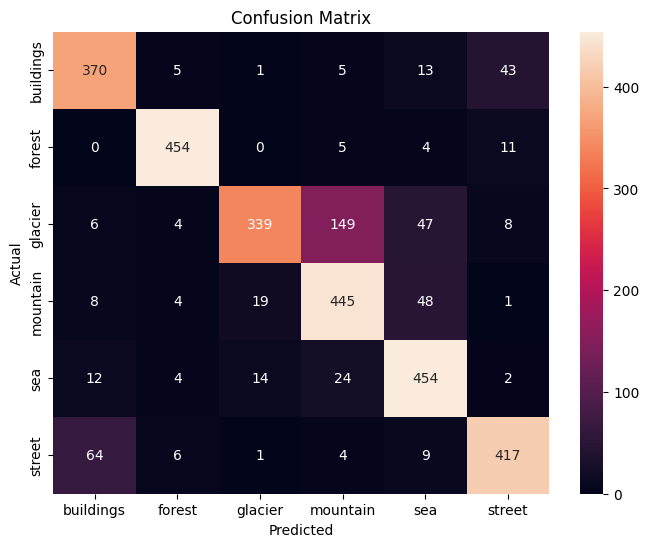

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.80      0.85      0.82       437
      forest       0.95      0.96      0.95       474
     glacier       0.91      0.61      0.73       553
    mountain       0.70      0.85      0.77       525
         sea       0.79      0.89      0.84       510
      street       0.87      0.83      0.85       501

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.83      0.82      3000



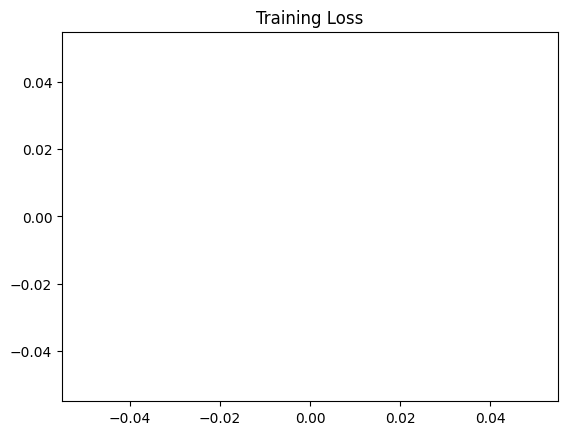

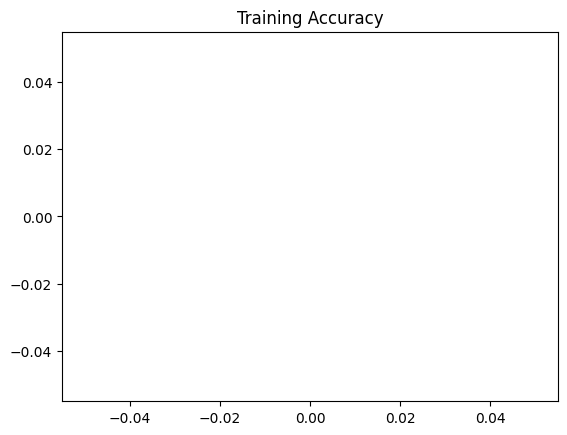

In [16]:
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.show()

plt.plot(train_acc_list)
plt.title("Training Accuracy")
plt.show()

# 7. Analysis

The model performed well on most classes such as sea and forest. However, some confusion was observed between similar classes like glacier and mountain. This indicates that visually similar features can affect classification accuracy.

In [17]:
print(len(train_loss_list))
print(len(train_acc_list))

0
0


In [18]:
torch.save(model.state_dict(), "cnn_model.pth")

In [19]:
torch.save(model.state_dict(), "/content/cnn_model.pth")

# 8. Conclusion

The CNN model achieved satisfactory performance in classifying natural scene images. Future improvements could include deeper architectures, data augmentation, and hyperparameter tuning.